# DocTR and OCR

Install packages

In [36]:
!pip install python-doctr[viz] opencv-python numpy
!pip install pytesseract

Import detection predictor

List of all models:
https://mindee.github.io/doctr/using_doctr/using_models.html

In [1]:
import cv2 as cv
import json
from doctr.models import detection_predictor

model = detection_predictor('db_resnet50', pretrained=True, assume_straight_pages=False, preserve_aspect_ratio=True)

image = cv.imread("test/test-Yves_026_None.png")
out = model([image])

print(out[0])


/home/bas/Documents/Visual Code Repo's/BelHisFirm-BelHisHAAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'words': array([[[0.88871704, 0.90722656],
        [0.94424804, 0.90722656],
        [0.94424804, 0.91699219],
        [0.88871704, 0.91699219],
        [0.        , 0.6002331 ]],

       [[0.94851966, 0.90722656],
        [0.96275838, 0.90722656],
        [0.96275838, 0.91503906],
        [0.94851966, 0.91503906],
        [0.        , 0.51526007]],

       [[0.84457701, 0.90625   ],
        [0.88444542, 0.90625   ],
        [0.88444542, 0.91601562],
        [0.84457701, 0.91601562],
        [0.        , 0.60830068]],

       ...,

       [[0.4288064 , 0.0625    ],
        [0.45585997, 0.0625    ],
        [0.45585997, 0.07226562],
        [0.4288064 , 0.07226562],
        [0.        , 0.63086162]],

       [[0.36900378, 0.06152344],
        [0.42311092, 0.06152344],
        [0.42311092, 0.07128906],
        [0.36900378, 0.07128906],
        [0.        , 0.67424091]],

       [[0.13833653, 0.05957031],
        [0.17250945, 0.05957031],
        [0.17250945, 0.07324219],
        [0.1383

### The output of detection_predictor of DocTR is structured as follows:

Structure: A dictionary with a 'words' key containing a NumPy array

Shape: (766, 5, 2) - This means 766 detected text regions, each defined by 5 coordinate pairs

Coordinates: Each text region is represented by 4 corner points plus a confidence score:

The first 4 coordinate pairs [x, y] define the bounding box corners of detected text

The 5th element [0.0, confidence_score] contains the confidence score for that detection

All coordinates are normalized (between 0 and 1) relative to the image dimensions

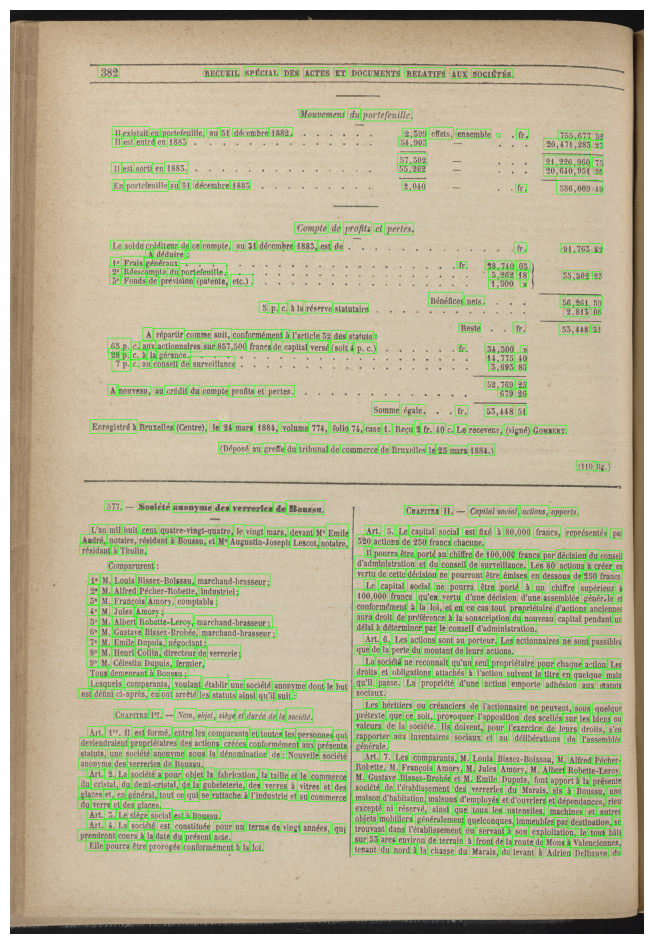

In [3]:
words_array = out[0]['words']
image_drawing = image.copy()
for i, box in enumerate(words_array):
    
    # Extract these pairs, I think the others can work to
    x1 = box[0][0]
    y1 = box[0][1]
    x2 = box[2][0]
    y2 = box[2][1]

    # Normalization
    h, w = image.shape[:2]
    pt1 = (int(x1 * w), int(y1 * h))
    pt2 = (int(x2 * w), int(y2 * h))
    cv.rectangle(image_drawing, pt1, pt2, (0, 255, 0), 2)

# Use matplotlib to display the image in Jupyter Notebook
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.imshow(cv.cvtColor(image_drawing, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


## Word level OCR comparison

## Tesseract

In [4]:
import pytesseract

teseract_text = []

def clamp_box(x0, y0, x1, y1, image_width, image_height):
    x0, x1 = sorted([max(0, min(x0, image_width - 1)), max(0, min(x1, image_width - 1))])
    y0, y1 = sorted([max(0, min(y0, image_height - 1)), max(0, min(y1, image_height - 1))])
    return x0, y0, x1, y1

for i, box in enumerate(words_array):
    
    # Extract and denormalize the four bounding box coordinates
    x1 = int(box[0][0] * w)
    y1 = int(box[0][1] * h)
    x2 = int(box[2][0] * w)
    y2 = int(box[2][1] * h)

    # Use pytesseract to extract text from the image

    x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, image.shape[1], image.shape[0])
    crop = image[y1:y2, x1:x2]

    try:
        text = pytesseract.image_to_string(crop, lang='fra', config='--psm 8')
        teseract_text.append(text)
        if i % 50 == 0:
            print(f"Step: {i}, Text: {text}")
    except Exception as e:
        print(f"Error extracting text from box {y1, y2}, {x1, x2}: {e}")





Step: 0, Text: Delbauve.

Step: 50, Text: à

Step: 100, Text: ‘du

Step: 150, Text: la

Step: 200, Text: 
Step: 250, Text: de

Step: 300, Text: une

Step: 350, Text: ‘directeur

Step: 400, Text: ‘capital

Step: 450, Text: chiffre

Step: 500, Text: être

Step: 550, Text: anonvenie

Step: 600, Text: pertes.

Step: 650, Text: répartir

Step: 700, Text: de

Step: 750, Text: 1889,



## Generate a fake transcribed page

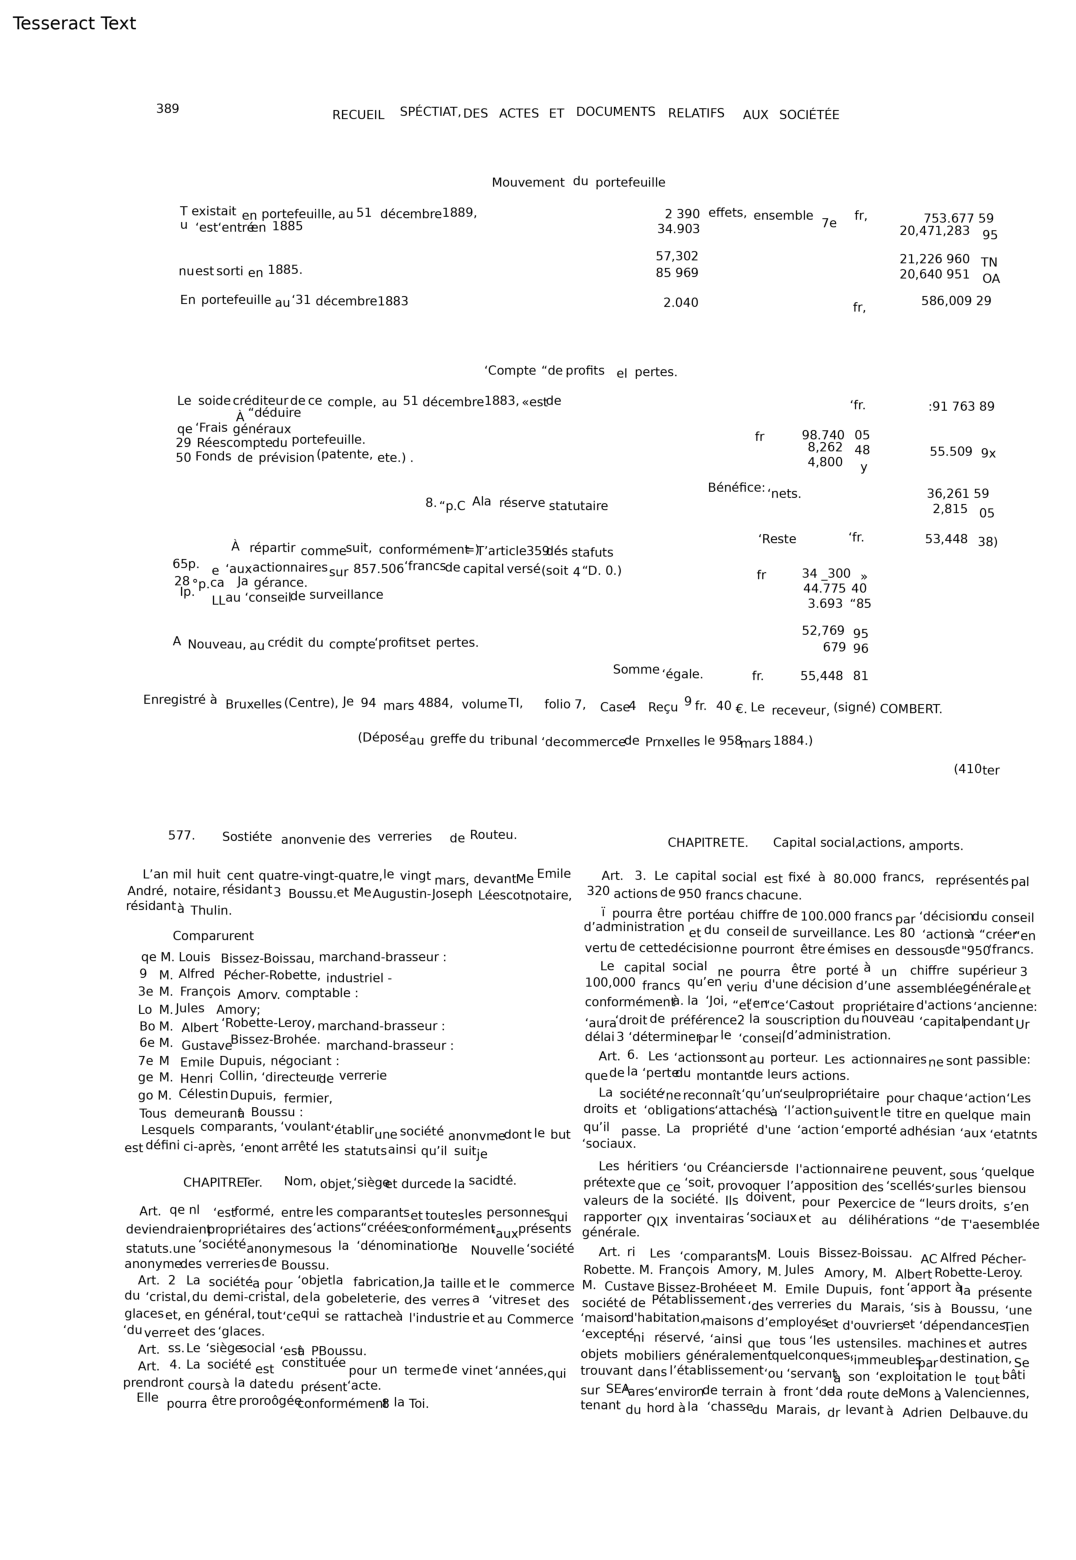

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

white_page = np.ones((h, w), dtype=np.uint8) * 255
pil_img = Image.fromarray(white_page)
draw = ImageDraw.Draw(pil_img)

font = ImageFont.truetype("DejaVuSans.ttf", 42)
title_font = ImageFont.truetype("DejaVuSans.ttf", 60)

for i, box in enumerate(words_array):
    x1 = int(box[0][0] * w)
    y1 = int(box[0][1] * h)
    x2 = int(box[2][0] * w)
    y2 = int(box[2][1] * h)

    x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, image.shape[1], image.shape[0])

    center = ((x1, (y1)))
    draw.text(center, teseract_text[i], font=font, fill=(0))



draw.text((10, 10), "Tesseract Text", font=title_font, fill=(0))
white_page = np.array(pil_img)

plt.figure(figsize=(20, 20))
plt.imshow(cv.cvtColor(white_page, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Qwen VL 2.5

In [2]:
!pip install transformers accelerate bitsandbytes qwen_vl_utils 
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [13]:
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
import base64

qwen_text = []


model = Qwen2VLForConditionalGeneration.from_pretrained("Qwen/Qwen2-VL-7B-Instruct", torch_dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=128 * 28 * 28, max_pixels=512 * 28 * 28)



for i, box in enumerate(words_array):
    x1 = int(box[0][0] * w)
    y1 = int(box[0][1] * h)
    x2 = int(box[2][0] * w)
    y2 = int(box[2][1] * h)


    x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, image.shape[1], image.shape[0])
    crop = image[y1:y2, x1:x2]
    _, buffer = cv.imencode('.png', crop)
    encoded_image = base64.b64encode(buffer).decode('utf-8')

    prompt = (f"Transcribe the word. Return only the word, no other text.")
    message = [
                            {
                                "role": "user",
                                "content": [
                                    {"type": "image", "image": f"data:image/png;base64,{encoded_image}"},
                                    {"type": "text", "text": prompt},
                                ],
                            }
                        ]
                    
    text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(message)
    inputs = processor(
                            text=[text],
                            images=image_inputs,
                            videos=video_inputs,
                            padding=True,
                            return_tensors="pt",
                        )
    inputs = inputs.to("cuda")

    generated_ids = model.generate(**inputs, max_new_tokens=12)
    generated_ids_trimmed = [
                        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
                        ]
    text = processor.batch_decode(
                            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
                        )

    if i % 50 == 0:
        print(f"Step: {i}, Text: {text[0]}")

    qwen_text.append(text[0])


Loading checkpoint shards: 100%|██████████| 5/5 [00:01<00:00,  3.15it/s]


Step: 0, Text: Delbouye
Step: 50, Text: ca
Step: 100, Text: du
Step: 150, Text: la
Step: 200, Text: 2
Step: 250, Text: de
Step: 300, Text: une
Step: 350, Text: directeur
Step: 400, Text: capital
Step: 450, Text: chiffre
Step: 500, Text: être
Step: 550, Text: anonyme
Step: 600, Text: pertes
Step: 650, Text: répartir
Step: 700, Text: de
Step: 750, Text: 1882


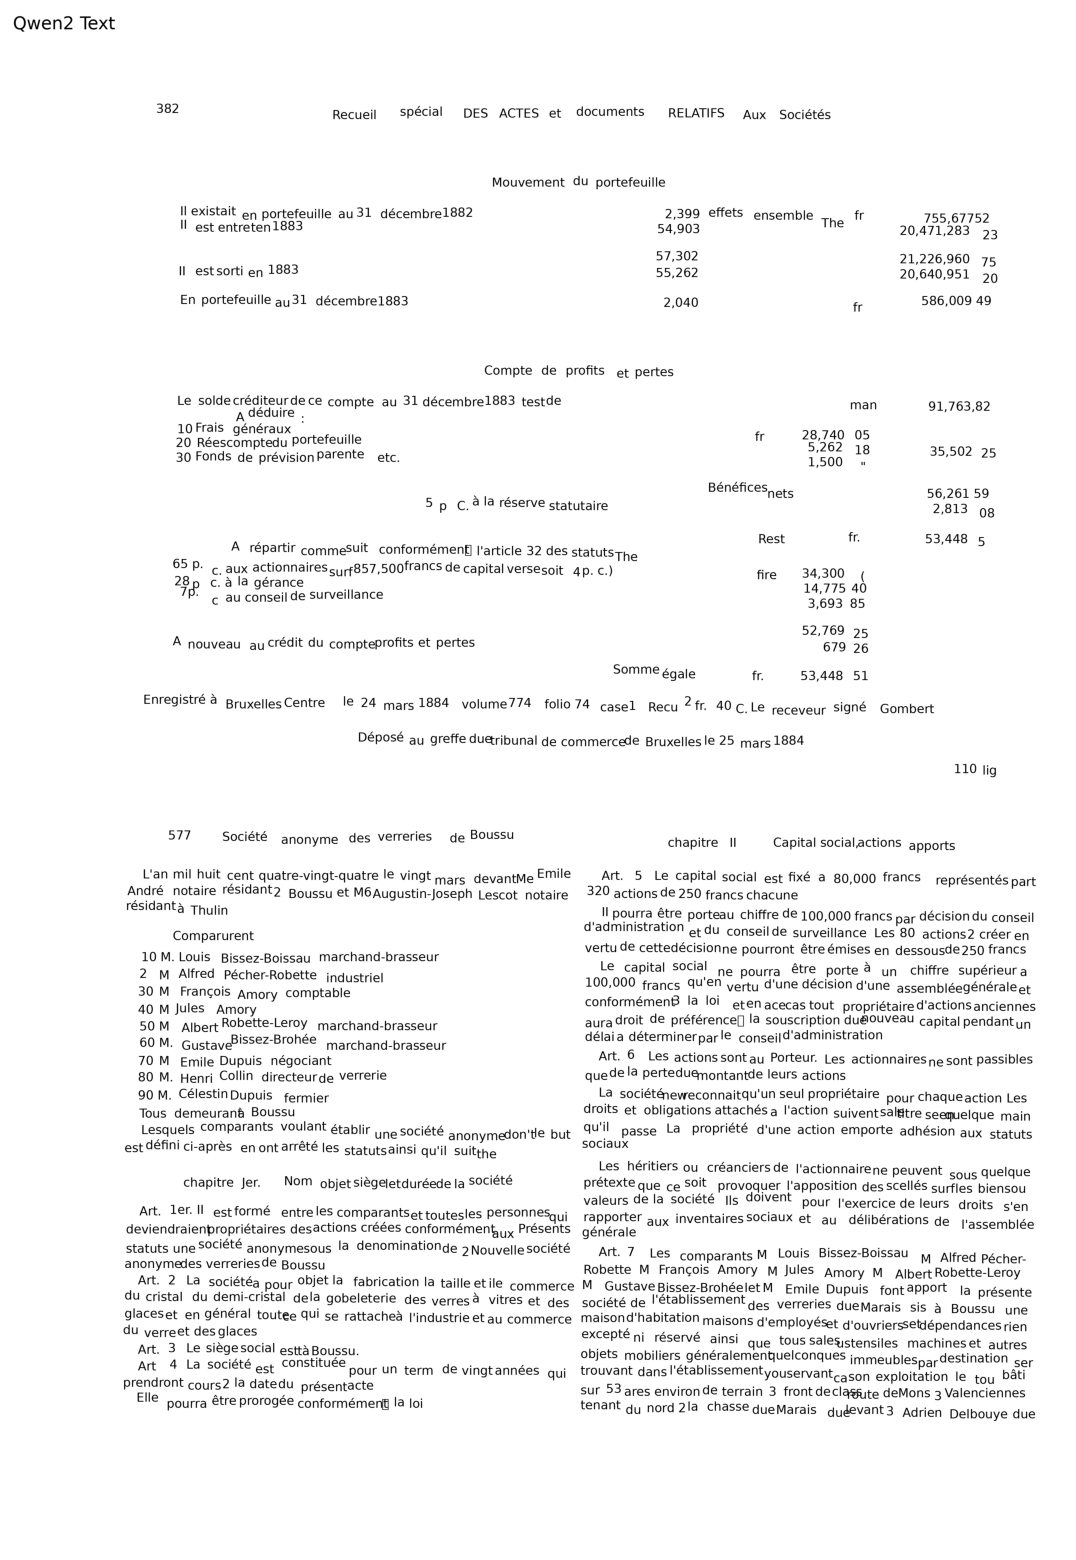

In [22]:
white_page = np.ones((h, w), dtype=np.uint8) * 255
pil_img = Image.fromarray(white_page)
draw = ImageDraw.Draw(pil_img)

font = ImageFont.truetype("DejaVuSans.ttf", 42)
title_font = ImageFont.truetype("DejaVuSans.ttf", 60)

for i, box in enumerate(words_array):
    x1 = int(box[0][0] * w)
    y1 = int(box[0][1] * h)
    x2 = int(box[2][0] * w)
    y2 = int(box[2][1] * h)

    x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, image.shape[1], image.shape[0])

    center = ((x1, (y1)))
    draw.text(center, qwen_text[i], font=font, fill=(0))

draw.text((10, 10), "Qwen2 Text", font=title_font, fill=(0))

white_page = np.array(pil_img)

plt.figure(figsize=(20, 20))
plt.imshow(cv.cvtColor(white_page, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Clean VRAM etc..

In [25]:
import torch 
import gc

del model
del processor
del inputs

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()

3210

# Export OCR data to VIA for validation

In [28]:
import json
import os

image_path = "test/test-Yves_026_None.png"

def coco_like_to_via(words_array, texts, image_path, image_height, image_width):
    file_name = os.path.basename(image_path)
    regions = []

    for box, text in zip(words_array, texts):
        # Convert normalized coordinates to absolute pixel positions
        pts = [(float(x) * image_width, float(y) * image_height) for x, y in box]
        all_points_x = [pt[0] for pt in pts]
        all_points_y = [pt[1] for pt in pts]

        region = {
            "shape_attributes": {
                "name": "polygon",
                "all_points_x": all_points_x,
                "all_points_y": all_points_y
            },
            "region_attributes": {
                "text": text.strip() if isinstance(text, str) else text
            }
        }
        regions.append(region)

    via_dict = {
        file_name: {
            "filename": file_name,
            "size": 0,  # Optional, can use os.path.getsize(image_path)
            "regions": regions,
            "file_attributes": {}
        }
    }

    return via_dict




via_annotations_qwen = coco_like_to_via(words_array, qwen_text, image_path, h, w)

# Save to file
output_path = os.path.join("test", f"{os.path.splitext(os.path.basename(image_path))[0]}_via.json")
os.makedirs("test", exist_ok=True)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(via_annotations_qwen, f, ensure_ascii=False, indent=2)

print(f"VIA JSON saved to {output_path}")

VIA JSON saved to test/test-Yves_026_None_via.json
